# Поиск по изображениям

## Цель проекта

Необходимо разработать прототип поиска изображений по текстовому описанию.

Для каждой пары «изображение — текст» модель должна оценивать степень их соответствия числом от 0 до 1.

В проекте:
- исследуем и подготавливаем данные;
- агрегируем экспертные оценки;
- исключаем потенциально детский контент из обучающей выборки;
- векторизуем изображения и тексты;
- объединяем признаки;
- обучаем модели предсказания соответствия;
- реализуем поиск по тестовым изображениям;
- визуально проверяем результаты.

In [12]:
import os
import pandas as pd

PATH = '/home/jovyan/work/project_4/data/to_upload'

# Основной датасет
train_df = pd.read_csv(
    os.path.join(PATH, 'train_dataset.csv')
)

# Оценки пользователей
crowd_df = pd.read_csv(
    os.path.join(PATH, 'CrowdAnnotations.tsv'),
    sep='\t',
    header=None,
    names=[
        'image',
        'query_id',
        'agreement',
        'count_match',
        'count_mismatch'
    ]
)

# Оценки экспертов
expert_df = pd.read_csv(
    os.path.join(PATH, 'ExpertAnnotations.tsv'),
    sep='\t',
    header=None,
    names=[
        'image',
        'query_id',
        'expert_1',
        'expert_2',
        'expert_3'
    ]
)

# Тестовые запросы
test_queries = pd.read_csv(
    os.path.join(PATH, 'test_queries.csv'),
    sep='|'
)

print('Размеры таблиц:')
print(f'train_dataset:      {train_df.shape}')
print(f'CrowdAnnotations:   {crowd_df.shape}')
print(f'ExpertAnnotations:  {expert_df.shape}')

print('\nКолонки:')
print('train:', train_df.columns.tolist())
print('crowd:', crowd_df.columns.tolist())
print('expert:', expert_df.columns.tolist())
print('test:', test_queries.columns.tolist())

Размеры таблиц:
train_dataset:      (5822, 3)
CrowdAnnotations:   (47830, 5)
ExpertAnnotations:  (5822, 5)

Колонки:
train: ['image', 'query_id', 'query_text']
crowd: ['image', 'query_id', 'agreement', 'count_match', 'count_mismatch']
expert: ['image', 'query_id', 'expert_1', 'expert_2', 'expert_3']
test: ['Unnamed: 0', 'query_id', 'query_text', 'image']


## 1. Исследовательский анализ данных

Сначала изучим структуру исходных данных, количество изображений и текстовых запросов, количество описаний на одно изображение и наличие пропусков.

Один объект обучающей выборки представляет собой пару «изображение — текстовое описание».

In [13]:
print('=== Общая информация ===')

print(f'Количество обучающих пар: {len(train_df):,}')
print(f'Уникальных изображений в train: {train_df["image"].nunique():,}')
print(f'Уникальных запросов в train: {train_df["query_id"].nunique():,}')

print(f'\nУникальных изображений в test: {test_queries["image"].nunique():,}')
print(f'Количество тестовых запросов: {len(test_queries):,}')

print('\nКоличество описаний на изображение:')
print(train_df.groupby('image')['query_id'].count().value_counts().sort_index())

print('\nПропуски:')
print(train_df.isna().sum())
print(crowd_df.isna().sum())
print(expert_df.isna().sum())
print(test_queries.isna().sum())

=== Общая информация ===
Количество обучающих пар: 5,822
Уникальных изображений в train: 1,000
Уникальных запросов в train: 977

Уникальных изображений в test: 100
Количество тестовых запросов: 500

Количество описаний на изображение:
2       8
3      49
4     157
5     228
6     233
7     164
8     114
9      37
10     10
Name: query_id, dtype: int64

Пропуски:
image         0
query_id      0
query_text    0
dtype: int64
image             0
query_id          0
agreement         0
count_match       0
count_mismatch    0
dtype: int64
image       0
query_id    0
expert_1    0
expert_2    0
expert_3    0
dtype: int64
Unnamed: 0    0
query_id      0
query_text    0
image         0
dtype: int64


### Экспертные оценки

Для каждой пары изображения и текста доступны оценки трёх экспертов по шкале от 1 до 4.

Сначала исследуем распределение этих оценок. Видно, что оценки смещены в сторону низких значений: большинство пар эксперты считают слабо соответствующими друг другу.

Уникальные экспертные оценки:
1    9797
2    4997
3    1701
4     971
dtype: int64


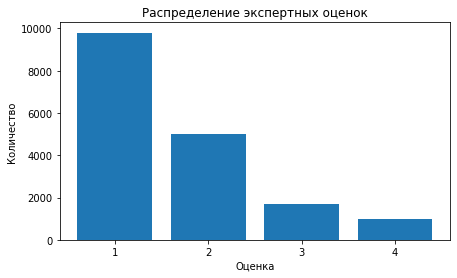

In [15]:
import matplotlib.pyplot as plt

expert_scores = expert_df[
    ['expert_1', 'expert_2', 'expert_3']
].values.flatten()

print('Уникальные экспертные оценки:')
print(pd.Series(expert_scores).value_counts().sort_index())

plt.figure(figsize=(7, 4))
plt.hist(
    expert_scores,
    bins=[0.5, 1.5, 2.5, 3.5, 4.5],
    rwidth=0.8
)
plt.xticks([1, 2, 3, 4])
plt.xlabel('Оценка')
plt.ylabel('Количество')
plt.title('Распределение экспертных оценок')
plt.show()

### Формирование целевой переменной

Для каждой пары возьмём среднее арифметическое трёх экспертных оценок.

Такой способ агрегации позволяет сохранить информацию о степени соответствия, а не только выбрать один из четырёх классов.

Полученную оценку переведём из диапазона 1–4 в диапазон 0–1:

`target = (expert_mean - 1) / 3`

Таким образом:
- 1 превращается в 0;
- 2 — в 0.33;
- 3 — в 0.67;
- 4 — в 1.

Полученный `target` можно интерпретировать как числовую оценку соответствия изображения тексту.

In [16]:
expert_df['expert_mean'] = expert_df[
    ['expert_1', 'expert_2', 'expert_3']
].mean(axis=1)

expert_df['target'] = (
    expert_df['expert_mean'] - 1
) / 3

print('Пример:')
display(
    expert_df[
        ['image', 'query_id', 'expert_1', 'expert_2',
         'expert_3', 'expert_mean', 'target']
    ].head(10)
)

print('\nРаспределение target:')
print(expert_df['target'].describe())

Пример:


,image,query_id,expert_1,expert_2,expert_3,expert_mean,target
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,1,1,1,1.000000,0.000000
1,1056338697_4f7d7ce270.jpg,2718495608_d8533e3ac5.jpg#2,1,1,2,1.333333,0.111111
2,1056338697_4f7d7ce270.jpg,3181701312_70a379ab6e.jpg#2,1,1,2,1.333333,0.111111
3,1056338697_4f7d7ce270.jpg,3207358897_bfa61fa3c6.jpg#2,1,2,2,1.666667,0.222222
4,1056338697_4f7d7ce270.jpg,3286822339_5535af6b93.jpg#2,1,1,2,1.333333,0.111111
5,1056338697_4f7d7ce270.jpg,3360930596_1e75164ce6.jpg#2,1,1,1,1.000000,0.000000
6,1056338697_4f7d7ce270.jpg,3545652636_0746537307.jpg#2,1,1,1,1.000000,0.000000
7,1056338697_4f7d7ce270.jpg,434792818_56375e203f.jpg#2,1,1,2,1.333333,0.111111
8,106490881_5a2dd9b7bd.jpg,1425069308_488e5fcf9d.jpg#2,1,1,1,1.000000,0.000000
9,106490881_5a2dd9b7bd.jpg,1714316707_8bbaa2a2ba.jpg#2,2,2,2,2.000000,0.333333



Распределение target:
count    5822.000000
mean        0.215886
std         0.268735
min         0.000000
25%         0.000000
50%         0.111111
75%         0.333333
max         1.000000
Name: target, dtype: float64


### Распределение целевой переменной

Распределение `target` смещено к низким значениям. Медиана равна 0.111, а среднее значение — около 0.216.

Следовательно, в датасете преобладают пары с небольшим соответствием изображения и текста.

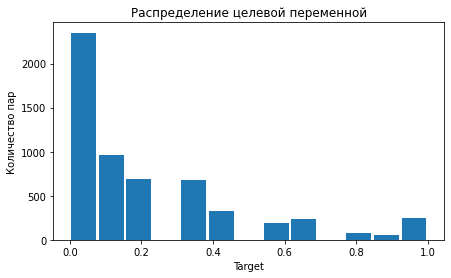

In [17]:
plt.figure(figsize=(7, 4))
plt.hist(expert_df['target'], bins=13, rwidth=0.9)
plt.xlabel('Target')
plt.ylabel('Количество пар')
plt.title('Распределение целевой переменной')
plt.show()

### Краудсорсинговые оценки

Дополнительно исследуем оценки краудсорсинга.

Параметр `agreement` показывает долю исполнителей, подтвердивших соответствие текста изображению.

Распределение сильно смещено к нулю: медианное значение `agreement` равно 0. Это означает, что большая часть дополнительно размеченных пар не была признана соответствующей.

Для формирования целевой переменной будем использовать экспертные оценки: они представлены для всех обучающих пар и дают более детальную шкалу оценки соответствия.

=== CrowdAnnotations ===
Статистика agreement:
count    47830.000000
mean         0.068786
std          0.207532
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: agreement, dtype: float64

Диапазон agreement:
min = 0.0 | max = 1.0

Количество уникальных значений agreement:
12

Примеры распределения:
0.000000    41970
0.166667        3
0.200000       22
0.250000       96
0.333333     3000
0.400000        8
0.500000       27
0.600000        8
0.666667     1360
0.750000        9
0.800000        4
1.000000     1323
Name: agreement, dtype: int64


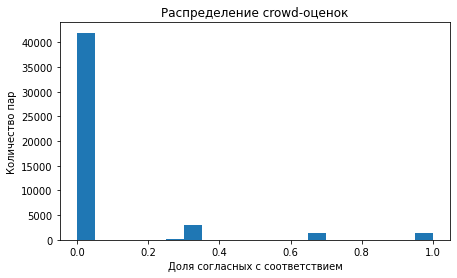

In [18]:
print('=== CrowdAnnotations ===')

print('Статистика agreement:')
print(crowd_df['agreement'].describe())

print('\nДиапазон agreement:')
print(
    'min =', crowd_df['agreement'].min(),
    '| max =', crowd_df['agreement'].max()
)

print('\nКоличество уникальных значений agreement:')
print(crowd_df['agreement'].nunique())

print('\nПримеры распределения:')
print(crowd_df['agreement'].value_counts().sort_index().head(20))

plt.figure(figsize=(7, 4))
plt.hist(crowd_df['agreement'], bins=20)
plt.xlabel('Доля согласных с соответствием')
plt.ylabel('Количество пар')
plt.title('Распределение crowd-оценок')
plt.show()

### Формирование единого датасета

Объединим основной датасет с агрегированными экспертными оценками по двум полям: `image` и `query_id`.

В результате для каждой обучающей пары получим текстовое описание и соответствующий `target`.

In [19]:
model_df = train_df.merge(
    expert_df[
        ['image', 'query_id', 'expert_mean', 'target']
    ],
    on=['image', 'query_id'],
    how='inner'
)

print('Размер итогового датасета:', model_df.shape)

print('\nПроверка:')
print('Строк в train_df:', len(train_df))
print('Строк после объединения:', len(model_df))
print('Пропусков target:', model_df['target'].isna().sum())

display(model_df.head())

Размер итогового датасета: (5822, 5)

Проверка:
Строк в train_df: 5822
Строк после объединения: 5822
Пропусков target: 0


,image,query_id,query_text,expert_mean,target
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...,1.000000,0.000000
1,1262583859_653f1469a9.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...,1.000000,0.000000
2,2447284966_d6bbdb4b6e.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...,1.666667,0.222222
3,2549968784_39bfbe44f9.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...,4.000000,1.000000
4,2621415349_ef1a7e73be.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...,1.000000,0.000000


## 2. Проверка данных и юридические ограничения

По условию проекта необходимо исключить из обучающей выборки контент, связанный с детьми младше 16 лет.

Поскольку в PoC нет отдельного классификатора возраста, будем использовать консервативную фильтрацию текстовых описаний по словам и выражениям, явно указывающим на ребёнка.

Для поиска используем границы слова, чтобы не находить случайные совпадения внутри других слов.

Дополнительно учитываем явные указания возраста младше 16 лет.

In [21]:
import re

# Слова и выражения, которые явно указывают на ребёнка
child_terms = [
    'child',
    'children',
    'kid',
    'kids',
    'boy',
    'boys',
    'girl',
    'girls',
    'baby',
    'babies',
    'infant',
    'infants',
    'toddler',
    'toddlers',
    'newborn',
    'newborns',
    'preschooler',
    'preschoolers',
    'schoolboy',
    'schoolboys',
    'schoolgirl',
    'schoolgirls',
    'preteen',
    'preteens',
    'minor',
    'minors',
    'juvenile',
    'juveniles'
]

# Ищем именно отдельные слова, а не части других слов
child_pattern = r'\b(?:' + '|'.join(map(re.escape, child_terms)) + r')\b'

# Дополнительно ловим явное указание возраста до 16 лет:
# "5 year old", "15-year-old", "under 16", "aged 12" и т.п.
age_pattern = (
    r'\b(?:'
    r'(?:[0-9]|1[0-5])[- ]year[- ]old'
    r'|'
    r'(?:[0-9]|1[0-5]) years? old'
    r'|'
    r'under 16'
    r'|'
    r'aged (?:[0-9]|1[0-5])'
    r')\b'
)

model_df['query_text_lower'] = (
    model_df['query_text']
    .fillna('')
    .str.lower()
)

model_df['is_child_content'] = (
    model_df['query_text_lower'].str.contains(
        child_pattern,
        regex=True,
        na=False
    )
    |
    model_df['query_text_lower'].str.contains(
        age_pattern,
        regex=True,
        na=False
    )
)

print('Проблемных обучающих пар:', model_df['is_child_content'].sum())
print(
    'Доля проблемных пар:',
    f"{model_df['is_child_content'].mean() * 100:.2f}%"
)

print('\nПримеры найденных описаний:')
display(
    model_df.loc[
        model_df['is_child_content'],
        ['image', 'query_text']
    ].head(20)
)

Проблемных обучающих пар: 1557
Доля проблемных пар: 26.74%

Примеры найденных описаний:


,image,query_text
0,1056338697_4f7d7ce270.jpg,A young child is wearing blue goggles and sitt...
1,1262583859_653f1469a9.jpg,A young child is wearing blue goggles and sitt...
2,2447284966_d6bbdb4b6e.jpg,A young child is wearing blue goggles and sitt...
3,2549968784_39bfbe44f9.jpg,A young child is wearing blue goggles and sitt...
4,2621415349_ef1a7e73be.jpg,A young child is wearing blue goggles and sitt...
5,3030566410_393c36a6c5.jpg,A young child is wearing blue goggles and sitt...
6,3155451946_c0862c70cb.jpg,A young child is wearing blue goggles and sitt...
7,3222041930_f642f49d28.jpg,A young child is wearing blue goggles and sitt...
8,343218198_1ca90e0734.jpg,A young child is wearing blue goggles and sitt...
9,3718964174_cb2dc1615e.jpg,A young child is wearing blue goggles and sitt...


### Очистка обучающей выборки

Исключим найденные потенциально проблемные пары из обучающего датасета.

После фильтрации осталось 4265 пар и 993 уникальных изображения.
1557 пар, то есть 26.74% исходной выборки, были исключены.

In [24]:
model_df_clean = model_df.loc[
    ~model_df['is_child_content']
].copy()

print('До фильтрации:', len(model_df))
print('После фильтрации:', len(model_df_clean))
print('Удалено:', len(model_df) - len(model_df_clean))

print(
    'Доля удалённых:',
    f'{(len(model_df) - len(model_df_clean)) / len(model_df) * 100:.2f}%'
)

print(
    'Уникальных изображений после фильтрации:',
    model_df_clean['image'].nunique()
)

До фильтрации: 5822
После фильтрации: 4265
Удалено: 1557
Доля удалённых: 26.74%
Уникальных изображений после фильтрации: 993


## 3. Исследование текстовых описаний

Перед векторизацией изучим длину текстовых описаний.

В среднем описание содержит около 11.5 слов, медиана равна 11 словам. Большинство текстов достаточно короткие, поэтому для первого решения подойдёт TF-IDF.

Статистика длины описаний:
count    4265.000000
mean       11.524502
std         3.995885
min         2.000000
25%         9.000000
50%        11.000000
75%        13.000000
max        34.000000
Name: text_length, dtype: float64


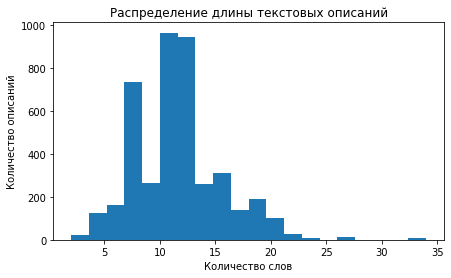

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Количество слов в каждом описании
model_df_clean['text_length'] = (
    model_df_clean['query_text']
    .str.split()
    .str.len()
)

print('Статистика длины описаний:')
print(model_df_clean['text_length'].describe())

plt.figure(figsize=(7, 4))
plt.hist(model_df_clean['text_length'], bins=20)
plt.xlabel('Количество слов')
plt.ylabel('Количество описаний')
plt.title('Распределение длины текстовых описаний')
plt.show()

### Частотность слов

В очищенной выборке встречается 1207 уникальных слов.

Среди наиболее частых есть как служебные слова, так и содержательные слова, связанные с объектами и действиями на изображениях. Для построения baseline используем TF-IDF.

In [26]:
from collections import Counter
import re

all_words = []

for text in model_df_clean['query_text']:
    words = re.findall(r'\b[a-z]+\b', text.lower())
    all_words.extend(words)

word_counts = Counter(all_words)

print('Количество уникальных слов:', len(word_counts))
print('\n20 самых частых слов:')

display(
    pd.DataFrame(
        word_counts.most_common(20),
        columns=['word', 'count']
    )
)

Количество уникальных слов: 1207

20 самых частых слов:


,word,count
0,a,6859
1,in,1983
2,the,1860
3,on,1147
4,dog,1138
5,and,925
6,is,920
7,man,918
8,with,685
9,of,655


## 4. Разбиение данных

Одно изображение связано с несколькими текстовыми описаниями, поэтому случайное разбиение по строкам может привести к утечке данных: одно и то же изображение окажется и в обучающей, и в проверочной выборке.

Используем `GroupShuffleSplit`, указав `image` в качестве группы.

Таким образом, все описания одного изображения целиком попадают только в одну из выборок.

In [27]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, val_idx = next(
    gss.split(
        model_df_clean,
        groups=model_df_clean['image']
    )
)

train_data = model_df_clean.iloc[train_idx].copy()
val_data = model_df_clean.iloc[val_idx].copy()

print('Размер train:', train_data.shape)
print('Размер validation:', val_data.shape)

print('\nУникальные изображения:')
print('Train:', train_data['image'].nunique())
print('Validation:', val_data['image'].nunique())

print(
    '\nПересечение изображений:',
    len(
        set(train_data['image'])
        & set(val_data['image'])
    )
)

Размер train: (3426, 8)
Размер validation: (839, 8)

Уникальные изображения:
Train: 794
Validation: 199

Пересечение изображений: 0


## 5. Векторизация текстов

Для представления текста используем TF-IDF.

Векторизатор обучаем только на тренировочной выборке, а validation преобразуем уже обученным преобразованием. Это предотвращает утечку информации из validation.

Используем униграммы и биграммы, чтобы учитывать не только отдельные слова, но и короткие фразы.

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    lowercase=True,
    max_features=1500,
    ngram_range=(1, 2),
    min_df=2
)

X_text_train = tfidf.fit_transform(train_data['query_text'])
X_text_val = tfidf.transform(val_data['query_text'])

print('Размер TF-IDF train:', X_text_train.shape)
print('Размер TF-IDF validation:', X_text_val.shape)
print('Размер словаря:', len(tfidf.vocabulary_))

Размер TF-IDF train: (3426, 1500)
Размер TF-IDF validation: (839, 1500)
Размер словаря: 1500


## 6. Векторизация изображений

Для получения признаков изображений воспользуемся предобученной ResNet50.

Классификационную верхушку сети удаляем и используем модель как извлекатель признаков. После Global Average Pooling каждое изображение представляется вектором размерности 2048.

Используем предварительно обученные на ImageNet веса, поэтому отдельно обучать свёрточную сеть на нашей небольшой выборке не требуется.

In [29]:
import os
import numpy as np
import tensorflow as tf

from tensorflow.keras.applications.resnet50 import (
    ResNet50,
    preprocess_input
)

RESNET_WEIGHTS = (
    '/datasets/keras_models/'
    'resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5'
)

assert os.path.exists(RESNET_WEIGHTS), (
    f'Файл весов не найден: {RESNET_WEIGHTS}'
)

image_model = ResNet50(
    weights=RESNET_WEIGHTS,
    include_top=False,
    pooling='avg',
    input_shape=(224, 224, 3)
)

print('Модель загружена')
print('Размер выхода:', image_model.output_shape)

2026-09-20 04:14:02.240053: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Модель загружена
Размер выхода: (None, 2048)


Сопоставим полученный embedding с каждым изображением в обучающей и валидационной выборках.

In [30]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array

def get_image_embeddings(image_names, image_dir, model, batch_size=32):
    embeddings = []

    for start in range(0, len(image_names), batch_size):
        batch_names = image_names[start:start + batch_size]
        batch_images = []

        for image_name in batch_names:
            image_path = os.path.join(image_dir, image_name)

            image = load_img(
                image_path,
                target_size=(224, 224)
            )

            image = img_to_array(image)
            batch_images.append(image)

        batch_images = np.array(batch_images, dtype=np.float32)
        batch_images = preprocess_input(batch_images)

        batch_embeddings = model.predict(
            batch_images,
            verbose=0
        )

        embeddings.append(batch_embeddings)

    return np.vstack(embeddings)

In [31]:
TRAIN_IMAGES_DIR = os.path.join(PATH, 'train_images')

all_train_images = model_df_clean['image'].unique()

print('Уникальных train-изображений:', len(all_train_images))

train_image_embeddings = get_image_embeddings(
    all_train_images,
    TRAIN_IMAGES_DIR,
    image_model,
    batch_size=32
)

print('Размер embeddings:', train_image_embeddings.shape)

Уникальных train-изображений: 993
Размер embeddings: (993, 2048)


In [32]:
image_to_embedding = {
    image_name: embedding
    for image_name, embedding in zip(
        all_train_images,
        train_image_embeddings
    )
}

X_image_train = np.vstack(
    train_data['image'].map(image_to_embedding)
)

X_image_val = np.vstack(
    val_data['image'].map(image_to_embedding)
)

print('X_image_train:', X_image_train.shape)
print('X_image_val:', X_image_val.shape)

X_image_train: (3426, 2048)
X_image_val: (839, 2048)


## 7. Объединение признаков

Объединим признаки изображения и текста в один вектор.

Для изображения используем 2048 признаков ResNet50, для текста — 1500 признаков TF-IDF.

Итоговая размерность признакового пространства составляет:

`2048 + 1500 = 3548 признаков`.

Целевая переменная — нормализованная экспертная оценка соответствия в диапазоне от 0 до 1.

In [33]:
X_text_train_dense = X_text_train.toarray()
X_text_val_dense = X_text_val.toarray()

X_train = np.hstack([
    X_image_train,
    X_text_train_dense
])

X_val = np.hstack([
    X_image_val,
    X_text_val_dense
])

y_train = train_data['target'].values
y_val = val_data['target'].values

print('X_train:', X_train.shape)
print('X_val:', X_val.shape)
print('y_train:', y_train.shape)
print('y_val:', y_val.shape)

X_train: (3426, 3548)
X_val: (839, 3548)
y_train: (3426,)
y_val: (839,)


## 8. Обучение модели предсказания соответствия

### Linear Regression

В качестве baseline обучим линейную регрессию.

Для оценки качества используем:
- MAE — среднюю абсолютную ошибку;
- RMSE — корень из средней квадратичной ошибки, который сильнее штрафует большие ошибки.

Линейная регрессия на объединённых признаках оказалась нестабильной: до ограничения диапазона её прогнозы имеют очень большие по модулю значения.

Это связано с высокой размерностью и сильной зависимостью признаков. Поэтому данную модель рассматриваем как baseline, а не как итоговое решение.

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_val)

# Так как целевая переменная находится в диапазоне 0–1,
# ограничим предсказания этим диапазоном.
y_pred_lr_clipped = np.clip(y_pred_lr, 0, 1)

mae_lr = mean_absolute_error(y_val, y_pred_lr_clipped)
rmse_lr = np.sqrt(mean_squared_error(y_val, y_pred_lr_clipped))

print(f'MAE:  {mae_lr:.4f}')
print(f'RMSE: {rmse_lr:.4f}')

print('\nДиапазон предсказаний до clipping:')
print(f'min = {y_pred_lr.min():.4f}')
print(f'max = {y_pred_lr.max():.4f}')

print('\nДиапазон предсказаний после clipping:')
print(f'min = {y_pred_lr_clipped.min():.4f}')
print(f'max = {y_pred_lr_clipped.max():.4f}')

MAE:  0.5199
RMSE: 0.6474

Диапазон предсказаний до clipping:
min = -7950977605025.8037
max = 10136641148129.7129

Диапазон предсказаний после clipping:
min = 0.0000
max = 1.0000


Дополнительно проверим ранг матрицы признаков. Полученный ранг значительно меньше исходной размерности, что подтверждает сильную зависимость признаков.

Поэтому нестабильность Linear Regression ожидаема.

In [35]:
rank = np.linalg.matrix_rank(X_train)

print('Количество признаков:', X_train.shape[1])
print('Количество объектов:', X_train.shape[0])
print('Ранг матрицы признаков:', rank)

Количество признаков: 3548
Количество объектов: 3426
Ранг матрицы признаков: 1466


In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print('X_train_scaled:', X_train_scaled.shape)
print('X_val_scaled:', X_val_scaled.shape)

X_train_scaled: (3426, 3548)
X_val_scaled: (839, 3548)


### Масштабирование признаков

Перед обучением MLP стандартизируем признаки с помощью `StandardScaler`.

Параметры масштабирования рассчитываются только на тренировочной выборке, после чего то же преобразование применяется к validation.

In [37]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

mlp_model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
])

mlp_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mae',
    metrics=[
        tf.keras.metrics.MeanAbsoluteError(name='mae'),
        tf.keras.metrics.RootMeanSquaredError(name='rmse')
    ]
)

mlp_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               908544    
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 64)                16448     
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_2 (Dense)             (None, 1)                 65        
                                                                 
Total params: 925,057
Trainable params: 925,057
Non-trainable params: 0
_________________________________________________________________


### Обучение MLP

Для контроля переобучения используем `EarlyStopping`, а для уменьшения скорости обучения при отсутствии улучшения — `ReduceLROnPlateau`.

В ходе обучения ошибка на train продолжала снижаться, тогда как validation после лучшей эпохи перестала улучшаться. Поэтому механизм ранней остановки вернул веса лучшей эпохи.

In [38]:
callbacks = [
    EarlyStopping(
        monitor='val_mae',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

history = mlp_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=32,
    callbacks=callbacks,
    verbose=2
)

Epoch 1/50
108/108 - 2s - loss: 0.2192 - mae: 0.2192 - rmse: 0.3377 - val_loss: 0.2079 - val_mae: 0.2079 - val_rmse: 0.3216 - lr: 0.0010 - 2s/epoch - 19ms/step
Epoch 2/50
108/108 - 1s - loss: 0.1986 - mae: 0.1986 - rmse: 0.3128 - val_loss: 0.1959 - val_mae: 0.1959 - val_rmse: 0.2942 - lr: 0.0010 - 1s/epoch - 13ms/step
Epoch 3/50
108/108 - 1s - loss: 0.1852 - mae: 0.1852 - rmse: 0.2891 - val_loss: 0.1918 - val_mae: 0.1918 - val_rmse: 0.2878 - lr: 0.0010 - 1s/epoch - 13ms/step
Epoch 4/50
108/108 - 1s - loss: 0.1708 - mae: 0.1708 - rmse: 0.2722 - val_loss: 0.1830 - val_mae: 0.1830 - val_rmse: 0.2774 - lr: 0.0010 - 1s/epoch - 13ms/step
Epoch 5/50
108/108 - 1s - loss: 0.1619 - mae: 0.1619 - rmse: 0.2580 - val_loss: 0.1844 - val_mae: 0.1844 - val_rmse: 0.2760 - lr: 0.0010 - 1s/epoch - 14ms/step
Epoch 6/50
108/108 - 1s - loss: 0.1510 - mae: 0.1510 - rmse: 0.2485 - val_loss: 0.1818 - val_mae: 0.1818 - val_rmse: 0.2663 - lr: 0.0010 - 1s/epoch - 13ms/step
Epoch 7/50
108/108 - 1s - loss: 0.1432 -

In [39]:
mlp_results = mlp_model.evaluate(
    X_val_scaled,
    y_val,
    verbose=0
)

print(f'MLP MAE:  {mlp_results[1]:.4f}')
print(f'MLP RMSE: {mlp_results[2]:.4f}')

MLP MAE:  0.1708
MLP RMSE: 0.2484


MLP показала меньшую ошибку на validation по сравнению с Linear Regression.

Полученные значения:
- MAE = 0.1708;
- RMSE = 0.2484.

Эту модель будем использовать для дальнейшего поиска изображений.

## 9. Тестирование модели

Для тестирования загрузим embeddings всех тестовых изображений.

Для текстовых запросов используем уже обученный на train TF-IDF. Повторно обучать векторизатор на тестовых данных нельзя.

In [40]:
TEST_IMAGES_DIR = os.path.join(PATH, 'test_images')

test_image_names = test_queries['image'].unique()

print('Уникальных тестовых изображений:', len(test_image_names))

# Проверяем, что файлы существуют
missing_images = [
    image_name
    for image_name in test_image_names
    if not os.path.exists(os.path.join(TEST_IMAGES_DIR, image_name))
]

print('Отсутствующих файлов:', len(missing_images))

if missing_images:
    print('Примеры отсутствующих файлов:')
    print(missing_images[:10])

test_image_embeddings = get_image_embeddings(
    test_image_names,
    TEST_IMAGES_DIR,
    image_model,
    batch_size=32
)

print('Размер тестовых embeddings:', test_image_embeddings.shape)

Уникальных тестовых изображений: 100
Отсутствующих файлов: 0
Размер тестовых embeddings: (100, 2048)


In [41]:
X_test_text = tfidf.transform(
    test_queries['query_text']
)

print('Размер TF-IDF тестовых запросов:', X_test_text.shape)

Размер TF-IDF тестовых запросов: (500, 1500)


### Функция поиска

Для каждого текстового запроса:
1. получаем TF-IDF-вектор текста;
2. объединяем его с embedding каждого тестового изображения;
3. масштабируем признаки тем же `StandardScaler`;
4. получаем score с помощью MLP;
5. сортируем изображения по score и выбираем наиболее релевантные.

Для потенциально детского запроса поиск не выполняется и отображается предусмотренный законодательством дисклеймер.

In [42]:
from PIL import Image
from IPython.display import display

# Быстрая проверка юридического ограничения для тестового запроса
def is_child_query(text):
    text = str(text).lower()

    has_child_term = re.search(
        child_pattern,
        text
    ) is not None

    has_age_term = re.search(
        age_pattern,
        text
    ) is not None

    return has_child_term or has_age_term


def search_images(query_text, top_k=5):
    """
    Поиск наиболее подходящих тестовых изображений по текстовому запросу.

    Возвращает DataFrame с top_k результатами.
    Для потенциально детского контента поиск не выполняется.
    """

    # Юридическая проверка
    if is_child_query(query_text):
        print(
            'DISCLOSURE: the search result is not shown because '
            'the query may refer to content involving children '
            'under 16.'
        )
        return None

    # Векторизуем текст тем же TF-IDF, который обучался только на train
    query_vector = tfidf.transform([query_text]).toarray()

    # Повторяем текстовый вектор для всех 100 тестовых изображений
    query_vectors = np.repeat(
        query_vector,
        len(test_image_names),
        axis=0
    )

    # Объединяем текстовые и визуальные признаки
    X_search = np.hstack([
        test_image_embeddings,
        query_vectors
    ])

    # Используем тот же scaler, что был обучен на train
    X_search_scaled = scaler.transform(X_search)

    # Получаем score от 0 до 1
    scores = mlp_model.predict(
        X_search_scaled,
        verbose=0
    ).ravel()

    # Формируем результаты
    results = pd.DataFrame({
        'image': test_image_names,
        'score': scores
    }).sort_values(
        'score',
        ascending=False
    ).head(top_k)

    results = results.reset_index(drop=True)

    return results

Пример поиска

In [43]:
query = "A black dog running through the grass"

results = search_images(query, top_k=5)

display(results)

,image,score
0,3514297698_0512623955.jpg,0.773147
1,2709359730_13bca100af.jpg,0.740582
2,3154152744_4e93ec8a62.jpg,0.673031
3,3488087117_2719647989.jpg,0.655467
4,3466891862_9afde75568.jpg,0.630424


Запрос: A black dog running through the grass
Лучшее изображение: 3514297698_0512623955.jpg
Score: 0.7731


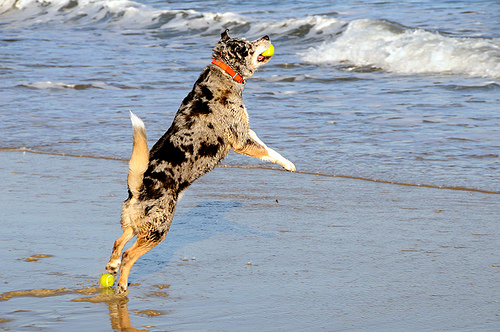

In [44]:
best_image = results.loc[0, 'image']
best_score = results.loc[0, 'score']

print('Запрос:', query)
print('Лучшее изображение:', best_image)
print(f'Score: {best_score:.4f}')

image_path = os.path.join(
    TEST_IMAGES_DIR,
    best_image
)

display(Image.open(image_path))

### Проверка юридического ограничения

Проверим работу поиска на запросе, связанном с детьми.

Вместо изображения система не выполняет поиск и выводит дисклеймер. Таким образом, юридическое ограничение реализовано и для тестовых запросов.

In [45]:
child_test_query = "Two young boys are playing football"

results_child = search_images(
    child_test_query,
    top_k=5
)

print('Результат:', results_child)

DISCLOSURE: the search result is not shown because the query may refer to content involving children under 16.
Результат: None


### Визуальная проверка

Согласно условию проекта выберем 10 случайных безопасных тестовых запросов и визуально сравним релевантное изображение с изображением, которое возвращает модель.

In [46]:
safe_test_queries = test_queries[
    ~test_queries['query_text'].apply(is_child_query)
].sample(
    10,
    random_state=42
).reset_index(drop=True)

display(
    safe_test_queries[
        ['query_id', 'query_text', 'image']
    ]
)

,query_id,query_text,image
0,1991806812_065f747689.jpg#2,a kickboxer jumping for a kick,1991806812_065f747689.jpg
1,661749711_6f408dad62.jpg#0,A dog jumps to catch a red ball outside .,661749711_6f408dad62.jpg
2,2714674623_8cd05ac114.jpg#4,"Three people , one wearing a t-shirt and baseb...",2714674623_8cd05ac114.jpg
3,3398788809_25c71ba018.jpg#2,A group of people playing instruments in the w...,3398788809_25c71ba018.jpg
4,2687672606_275169c35d.jpg#3,The lady in the multi-colored shirt has a neck...,2687672606_275169c35d.jpg
5,424307754_1e2f44d265.jpg#3,Man in field with a black dog jumping at his r...,424307754_1e2f44d265.jpg
6,3722572342_6904d11d52.jpg#3,A watercraft speeds through the water .,3722572342_6904d11d52.jpg
7,3356748019_2251399314.jpg#1,Three dirt bike racers head over a jump .,3356748019_2251399314.jpg
8,3438981089_2ef1a6353c.jpg#4,The man is performing a trick with an orange b...,3438981089_2ef1a6353c.jpg
9,3398788809_25c71ba018.jpg#4,Six men have a band practice in the woods .,3398788809_25c71ba018.jpg



1. a kickboxer jumping for a kick
Правильное изображение: 1991806812_065f747689.jpg
Найденное изображение:   3722572342_6904d11d52.jpg
Score: 0.4363
Правильное:


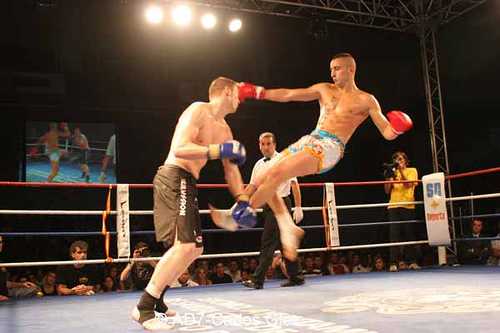

Результат поиска:


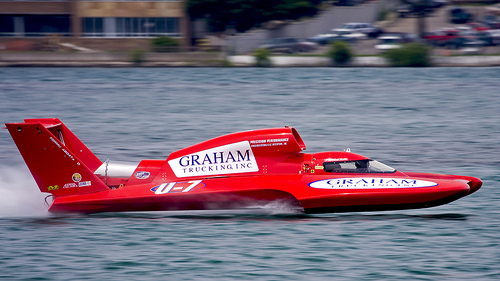


2. A dog jumps to catch a red ball outside .
Правильное изображение: 661749711_6f408dad62.jpg
Найденное изображение:   3514297698_0512623955.jpg
Score: 0.6535
Правильное:


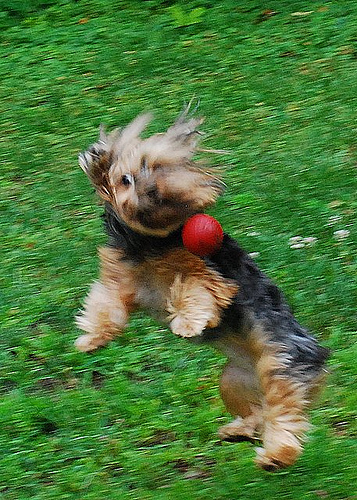

Результат поиска:


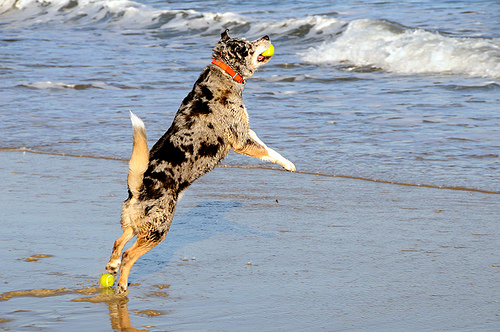


3. Three people , one wearing a t-shirt and baseball cap , are seated on a bus .
Правильное изображение: 2714674623_8cd05ac114.jpg
Найденное изображение:   3722572342_6904d11d52.jpg
Score: 0.4142
Правильное:


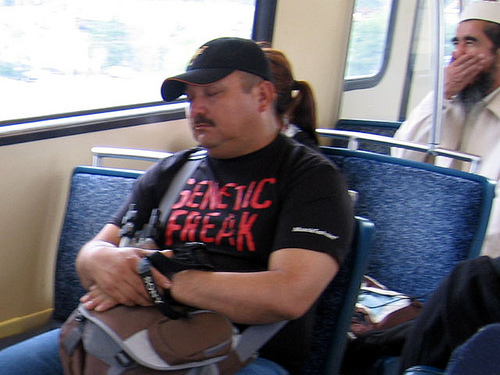

Результат поиска:


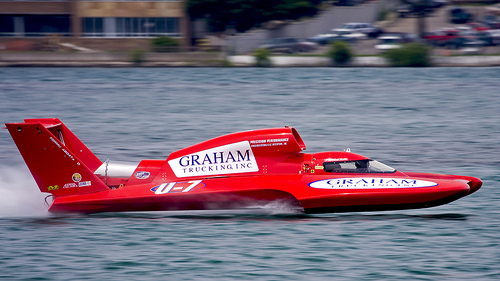


4. A group of people playing instruments in the woods .
Правильное изображение: 3398788809_25c71ba018.jpg
Найденное изображение:   3154152744_4e93ec8a62.jpg
Score: 0.4669
Правильное:


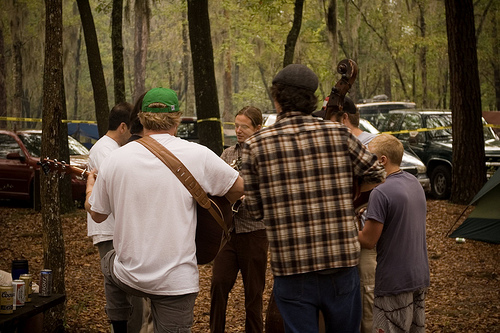

Результат поиска:


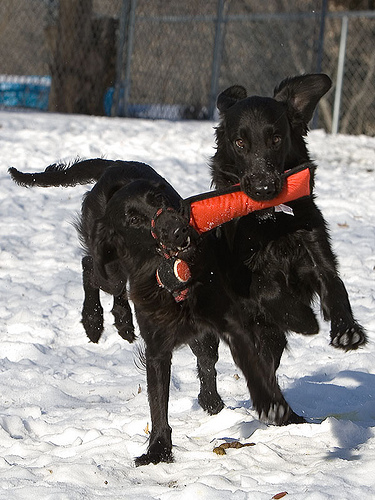


5. The lady in the multi-colored shirt has a necklace on a white object in her hand .
Правильное изображение: 2687672606_275169c35d.jpg
Найденное изображение:   3514297698_0512623955.jpg
Score: 0.4767
Правильное:


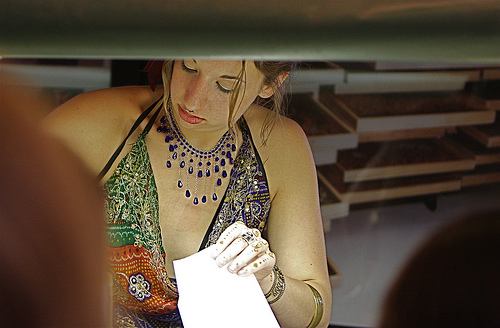

Результат поиска:


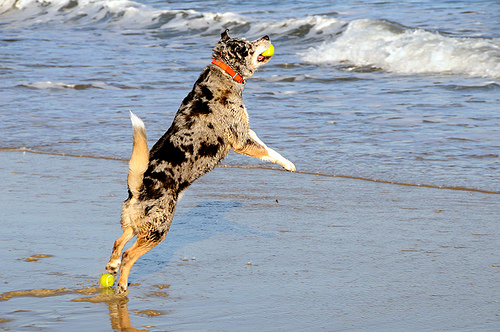


6. Man in field with a black dog jumping at his raised arm .
Правильное изображение: 424307754_1e2f44d265.jpg
Найденное изображение:   3514297698_0512623955.jpg
Score: 0.5974
Правильное:


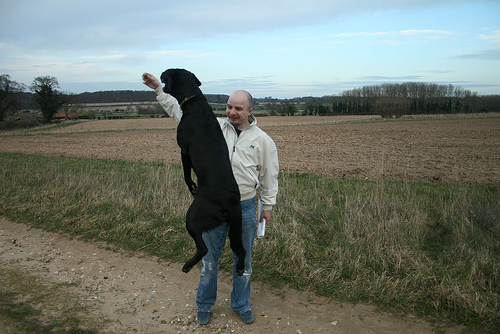

Результат поиска:


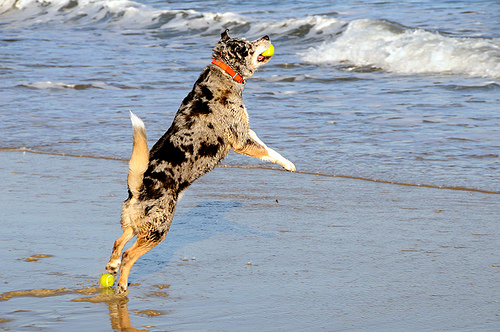


7. A watercraft speeds through the water .
Правильное изображение: 3722572342_6904d11d52.jpg
Найденное изображение:   3514297698_0512623955.jpg
Score: 0.7242
Правильное:


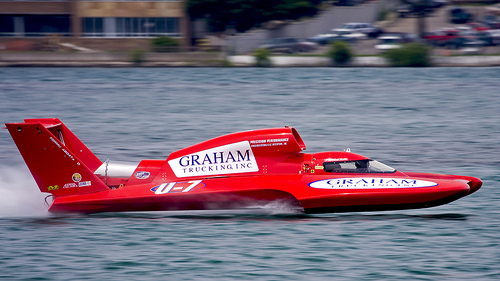

Результат поиска:


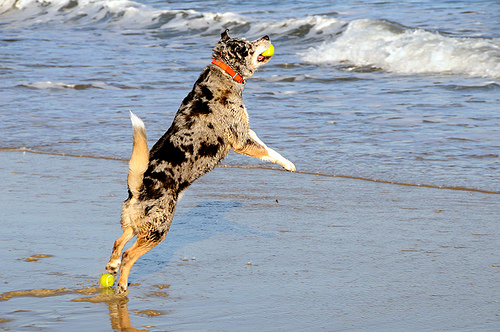


8. Three dirt bike racers head over a jump .
Правильное изображение: 3356748019_2251399314.jpg
Найденное изображение:   2428094795_d3a8f46046.jpg
Score: 0.5150
Правильное:


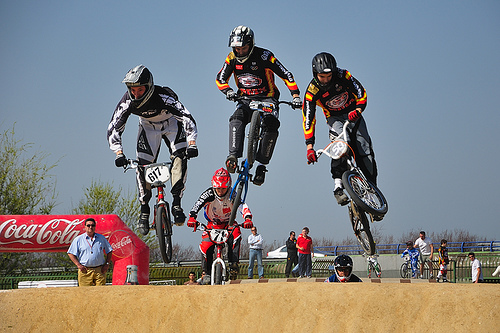

Результат поиска:


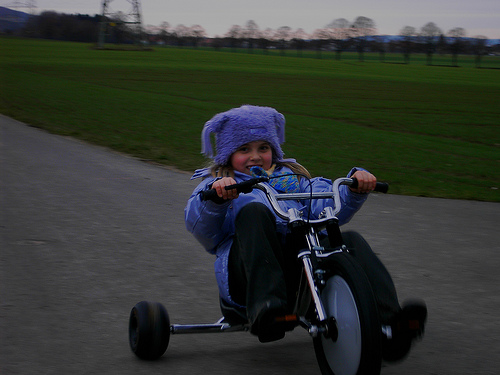


9. The man is performing a trick with an orange bicycle .
Правильное изображение: 3438981089_2ef1a6353c.jpg
Найденное изображение:   3438981089_2ef1a6353c.jpg
Score: 0.5322
Правильное:


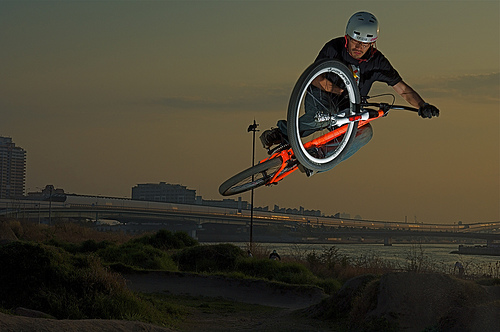

Результат поиска:


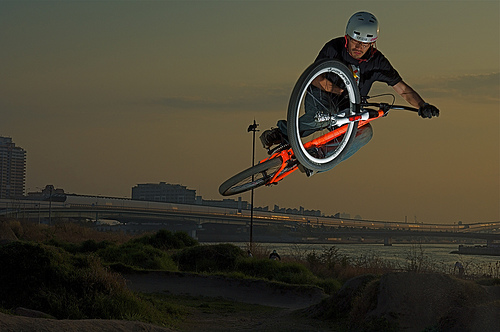


10. Six men have a band practice in the woods .
Правильное изображение: 3398788809_25c71ba018.jpg
Найденное изображение:   3154152744_4e93ec8a62.jpg
Score: 0.4638
Правильное:


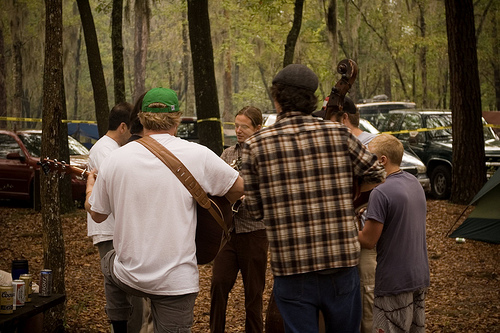

Результат поиска:


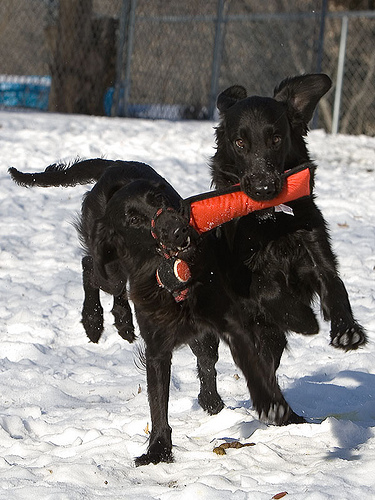

In [47]:
from IPython.display import display
from PIL import Image

for i, row in safe_test_queries.iterrows():
    query = row['query_text']
    true_image = row['image']

    results = search_images(query, top_k=1)

    if results is None:
        continue

    predicted_image = results.loc[0, 'image']
    score = results.loc[0, 'score']

    print(f'\n{i + 1}. {query}')
    print(f'Правильное изображение: {true_image}')
    print(f'Найденное изображение:   {predicted_image}')
    print(f'Score: {score:.4f}')

    print('Правильное:')
    display(Image.open(os.path.join(TEST_IMAGES_DIR, true_image)))

    print('Результат поиска:')
    display(Image.open(os.path.join(TEST_IMAGES_DIR, predicted_image)))

На 10 случайных безопасных запросах большинство найденных изображений не совпало с релевантным изображением из тестовой выборки.

Точное совпадение наблюдалось для одного из десяти запросов.

Это показывает, что хорошее качество предсказания числового `target` на validation не гарантирует высокого качества итогового поиска изображений.

### Дополнительная оценка поиска

Для количественного дополнения визуальной проверки рассчитаем Hit@1 и Hit@5.

На выборке из 10 случайных безопасных запросов:
- Hit@1 = 10%;
- Hit@5 = 10%.

Выборка слишком мала для устойчивой оценки качества, поэтому эти результаты рассматриваем как дополнительную иллюстрацию к визуальному анализу.

In [48]:
hit_at_1 = 0
hit_at_5 = 0

for _, row in safe_test_queries.iterrows():
    query = row['query_text']
    true_image = row['image']

    results = search_images(query, top_k=5)

    if results is None:
        continue

    predicted_images = results['image'].tolist()

    if true_image in predicted_images[:1]:
        hit_at_1 += 1

    if true_image in predicted_images:
        hit_at_5 += 1

n = len(safe_test_queries)

print(f'Hit@1: {hit_at_1}/{n} = {hit_at_1 / n:.2%}')
print(f'Hit@5: {hit_at_5}/{n} = {hit_at_5 / n:.2%}')

Hit@1: 1/10 = 10.00%
Hit@5: 1/10 = 10.00%


## 10. Сравнение моделей

Сравним качество двух моделей на validation по MAE и RMSE.

MLP показала существенно меньшую ошибку по обеим метрикам, поэтому для дальнейшего поиска используем именно её.

In [49]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'MLP'],
    'MAE': [mae_lr, mlp_results[1]],
    'RMSE': [rmse_lr, mlp_results[2]]
})

display(comparison)

,Model,MAE,RMSE
0,Linear Regression,0.519931,0.647361
1,MLP,0.170767,0.248430


## 11. Выводы

В работе был разработан прототип поиска изображений по текстовому описанию.

Исходная обучающая выборка содержит 5822 пары «изображение — описание» и 1000 уникальных изображений. Пропуски в данных отсутствуют.

Для формирования целевой переменной использованы экспертные оценки трёх специалистов. Мы рассчитали их среднее и нормализовали значение из диапазона 1–4 в диапазон 0–1.

CrowdAnnotations также были исследованы. Распределение crowd-оценок сильно смещено к нулю, поэтому для целевой переменной использованы экспертные оценки.

В рамках юридических требований из обучающей выборки были удалены пары, в текстовых описаниях которых обнаружены признаки потенциально детского контента. После фильтрации осталось 4265 пар и 993 изображения.

Для текстов использован TF-IDF с 1500 признаками, униграммами и биграммами.

Для изображений использована предобученная ResNet50 без классификационной верхушки. После Global Average Pooling размер embedding составил 2048 признаков.

Итоговый вектор пары «изображение — текст» содержит 3548 признаков.

Для предотвращения утечки данных использован GroupShuffleSplit по полю `image`. Пересечение изображений между обучающей и validation выборками отсутствует.

В качестве baseline была обучена Linear Regression. Она показала MAE = 0.5199 и RMSE = 0.6474 и оказалась нестабильной на исходном признаковом пространстве.

Полносвязная нейронная сеть MLP показала лучшие результаты:
- MAE = 0.1708;
- RMSE = 0.2484.

Поэтому MLP была использована для функции поиска.

Для тестирования реализован поиск среди 100 тестовых изображений: текст преобразуется в TF-IDF-вектор, объединяется с embedding каждого изображения, после чего MLP рассчитывает score соответствия.

Юридическое ограничение реализовано также для тестовых запросов: при обнаружении потенциально детского контента вместо изображения выводится дисклеймер.

На 10 случайных безопасных запросах проведена визуальная проверка качества поиска. Точное совпадение релевантного изображения с результатом поиска наблюдалось в одном из десяти случаев.

Таким образом, MLP хорошо предсказывает числовую оценку соответствия на validation, однако качество итогового поиска по изображениям остаётся ограниченным. Для дальнейшего улучшения модели можно исследовать более семантические способы векторизации текста и методы, ориентированные непосредственно на задачу поиска соответствующих изображений.